In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score
import torch

In [2]:
checkpoint = torch.load('data/models/cgcnn_noenv_best_optuna.pt',map_location=torch.device('cpu') )

# hidden_dim: look at the node embedding output size
hidden_dim = checkpoint['node_embedding.weight'].shape[0]  # rows = output features

# num_conv_layers: count how many conv_layers.X.lin_f.weight keys exist
num_conv_layers = sum(1 for k in checkpoint if 'lin_f.weight' in k)

print(f"hidden_dim: {hidden_dim}, num_conv_layers: {num_conv_layers}")

hidden_dim: 64, num_conv_layers: 4


In [9]:
preds_MP_env = np.genfromtxt('data/preds/MP_env.csv',delimiter = ',')
preds_MP_noenv = np.genfromtxt('data/preds/MP_noenv.csv',delimiter = ',')
preds_ICSD = np.genfromtxt('data/preds/ICSD.csv',delimiter=',')
preds_ICSD_real = np.genfromtxt('data/preds/ICSD_real.csv',delimiter=',')
preds_MPtest = np.genfromtxt('data/preds/ICSD_MPtest_preds.csv',delimiter=',')

targets_MP = np.genfromtxt('data/preds/targets_MP.csv',delimiter=',')
targets_ICSD = np.genfromtxt('data/preds/targets_ICSD.csv',delimiter=',')
targets_ICSD_real = np.genfromtxt('data/preds/targets_ICSD_real.csv',delimiter=',')
targets_MPtest = np.genfromtxt('data/preds/ICSD_MPtest_targets.csv',delimiter=',')

In [10]:
print(len(preds_ICSD))

15127


In [11]:
fpr_MP_env,tpr_MP_env,_ = roc_curve(targets_MP,preds_MP_env)
fpr_MP_noenv,tpr_MP_noenv,_ = roc_curve(targets_MP,preds_MP_noenv)
auc_MP_env = auc(fpr_MP_env,tpr_MP_env)
auc_MP_noenv = auc(fpr_MP_noenv,tpr_MP_noenv)


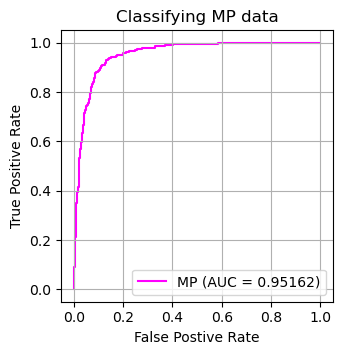

In [12]:
fig,ax = plt.subplots(1,1,figsize=(3.65,3.65))

# ax.plot(fpr_MP_env,tpr_MP_env,label=f'Incl. env. (AUC = {auc_MP_env:5.5f})',color='orange',alpha=0.6)
ax.plot(fpr_MP_noenv,tpr_MP_noenv,label=f'MP (AUC = {auc_MP_noenv:5.5f})',color='magenta',zorder=0)
ax.set_xlabel('False Postive Rate', size=10)
ax.set_ylabel('True Positive Rate', size=10)
ax.set_title(r'Classifying MP data')
ax.set_aspect('equal')
ax.grid()



ax.legend()
fig.tight_layout()
fig.savefig('figs/roc_MP.png')
plt.show()

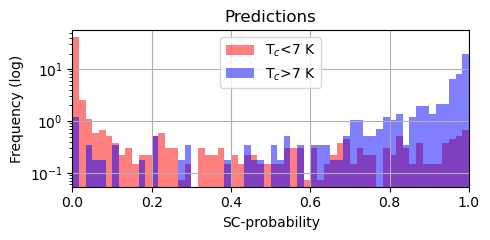

In [13]:
# # hists for MP
# fig,[axenv,axnoenv]=plt.subplots(2,1,sharex=True,figsize=(5,5))

# axenv.hist(preds_MP_env[targets_MP==0],alpha=0.5,color='red',density=True,bins=60,label=r'T$_c$<7 K')
# axenv.hist(preds_MP_env[targets_MP==1]  ,alpha=0.5,color='blue',density=True,bins=60,label=r'T$_c$>7 K')

# # axenv.set_xlabel('SC-probability')
# axenv.set_ylabel('Frequency (log)')
# axenv.set_yscale('log')
# axenv.set_title('Predictions: Incl. env.')
# axenv.grid()
# axenv.set_xlim(0,1)
# axenv.legend()

# axnoenv.hist(preds_MP_noenv[targets_MP==0],alpha=0.5,color='red',density=True,bins=60,label='Incl. env.')
# axnoenv.hist(preds_MP_noenv[targets_MP==1]  ,alpha=0.5,color='blue',density=True,bins=60,label='Incl. env.')

# axnoenv.set_xlabel('SC-probability')
# axnoenv.set_ylabel('Frequency (log)')
# axnoenv.set_yscale('log')
# axnoenv.set_title('Predictions: Excl. env.')
# axnoenv.grid()
# axnoenv.set_xlim(0,1)
# fig.tight_layout()
# fig.savefig('figs/MP_hist.png')
# plt.show()
# hists for MP
fig,axnoenv=plt.subplots(1,1,figsize=(5,5/2))

axnoenv.hist(preds_MP_noenv[targets_MP==0],alpha=0.5,color='red',density=True,bins=60,label=r'T$_c$<7 K')
axnoenv.hist(preds_MP_noenv[targets_MP==1]  ,alpha=0.5,color='blue',density=True,bins=60,label=r'T$_c$>7 K')

axnoenv.set_xlabel('SC-probability')
axnoenv.set_ylabel('Frequency (log)')
axnoenv.set_yscale('log')
axnoenv.set_title('Predictions')
axnoenv.grid()
axnoenv.set_xlim(0,1)
axnoenv.legend(loc='upper center')
fig.tight_layout()
fig.savefig('figs/MP_hist.png')
plt.show()

In [16]:
fpr_ICSD,tpr_ICSD,_ = roc_curve(targets_ICSD,preds_ICSD)
fpr_ICSD_real,tpr_ICSD_real,_ = roc_curve(targets_ICSD_real,preds_ICSD_real)
fpr_MPtest,tpr_MPtest,_ = roc_curve(targets_MPtest,preds_MPtest)
auc_ICSD = auc(fpr_ICSD,tpr_ICSD)
auc_ICSD_real = auc(fpr_ICSD_real,tpr_ICSD_real)

auc_MPtest = auc(fpr_MPtest,tpr_MPtest)

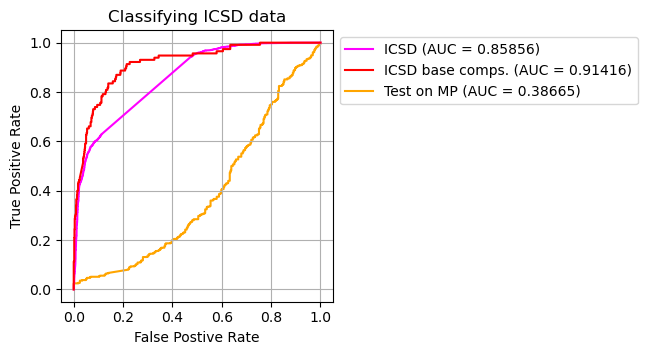

In [23]:
fig,ax = plt.subplots(1,1,figsize=(7,3.65))
ax.plot(fpr_ICSD,tpr_ICSD,label=f'ICSD (AUC = {auc_ICSD:5.5f})',color="magenta")
ax.plot(fpr_ICSD_real,tpr_ICSD_real,label=f'ICSD base comps. (AUC = {auc_ICSD_real:5.5f})',color="red")
ax.plot(fpr_MPtest,tpr_MPtest,label=f'Test on MP (AUC = {auc_MPtest:5.5f})',color='orange',zorder=0)
ax.set_xlabel('False Postive Rate', size=10)
ax.set_ylabel('True Positive Rate', size=10)
ax.set_title(r'Classifying ICSD data')
ax.set_aspect('equal')
ax.grid()

ax.legend(bbox_to_anchor=(1,1))
fig.tight_layout()
fig.savefig('figs/roc_ICSD.png')
plt.show()

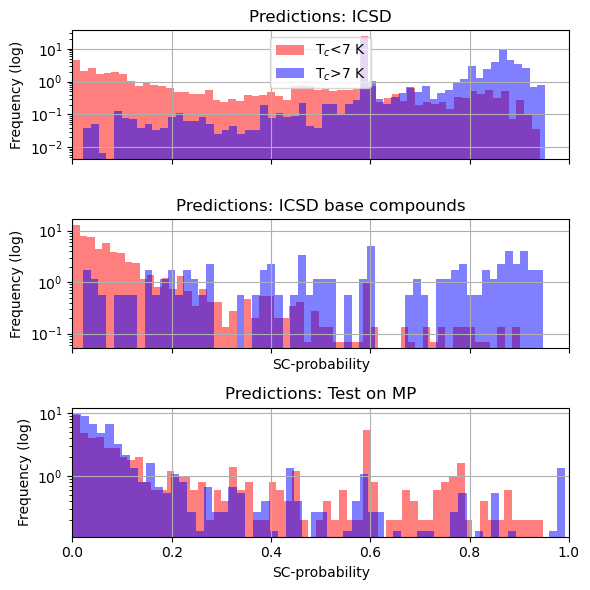

In [22]:
# hists for ICSD
fig,[axenv,axnoenv,axtest]=plt.subplots(3,1,sharex=True,figsize=(6,6))

axenv.hist(preds_ICSD[targets_ICSD==0],alpha=0.5,color='red',density=True,bins=60,label=r'T$_c$<7 K')
axenv.hist(preds_ICSD[targets_ICSD==1]  ,alpha=0.5,color='blue',density=True,bins=60,label=r'T$_c$>7 K')

# axenv.set_xlabel('SC-probability')
axenv.set_ylabel('Frequency (log)')
axenv.set_yscale('log')
axenv.set_title('Predictions: ICSD')
axenv.grid()
axenv.set_xlim(0,1)
axenv.legend()

axnoenv.hist(preds_ICSD_real[targets_ICSD_real==0],alpha=0.5,color='red',density=True,bins=60,label='Incl. env.')
axnoenv.hist(preds_ICSD_real[targets_ICSD_real==1]  ,alpha=0.5,color='blue',density=True,bins=60,label='Incl. env.')

axnoenv.set_xlabel('SC-probability')
axnoenv.set_ylabel('Frequency (log)')
axnoenv.set_yscale('log')
axnoenv.set_title('Predictions: ICSD base compounds')
axnoenv.grid()
axnoenv.set_xlim(0,1)

axtest.hist(preds_MPtest[targets_MPtest==0],alpha=0.5,color='red',density=True,bins=60,label='Incl. env.')
axtest.hist(preds_MPtest[targets_MPtest==1]  ,alpha=0.5,color='blue',density=True,bins=60,label='Incl. env.')

axtest.set_xlabel('SC-probability')
axtest.set_ylabel('Frequency (log)')
axtest.set_yscale('log')
axtest.set_title('Predictions: Test on MP')
axtest.grid()
axtest.set_xlim(0,1)
fig.tight_layout()
fig.savefig('figs/ICSD_hist.png')
plt.show()

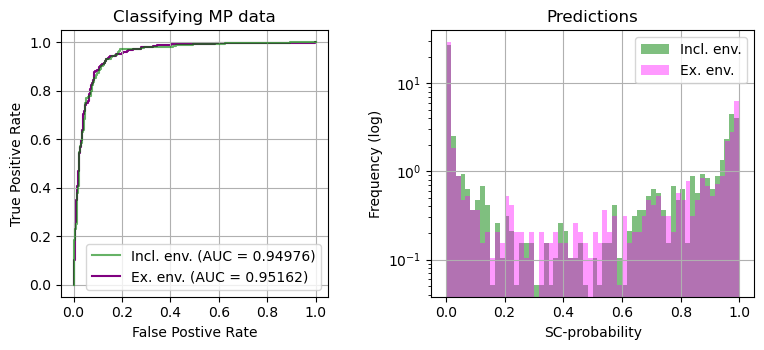

In [49]:
fig,[ax,axhist] = plt.subplots(1,2,figsize=(10*0.8,4.5*0.8))

ax.plot(fpr_MP_env,tpr_MP_env,label=f'Incl. env. (AUC = {auc_MP_env:5.5f})',color='green',alpha=0.6)
ax.plot(fpr_MP_noenv,tpr_MP_noenv,label=f'Ex. env. (AUC = {auc_MP_noenv:5.5f})',color='purple',zorder=0)
ax.set_xlabel('False Postive Rate', size=10)
ax.set_ylabel('True Positive Rate', size=10)
ax.set_title(r'Classifying MP data')
ax.set_aspect('equal')

axhist.hist(preds_MP_env,alpha=0.5,color='green',density=True,bins=60,label='Incl. env.')
axhist.hist(preds_MP_noenv,alpha=0.4,color='magenta',density=True,bins=60,label='Ex. env.')
axhist.set_xlabel('SC-probability')
axhist.set_ylabel('Frequency (log)')
axhist.set_yscale('log')
axhist.set_title('Predictions')
ax.grid()
axhist.grid()

ax.legend()
axhist.legend()
fig.tight_layout()
fig.savefig('figs/roc_MP.png')
plt.show()

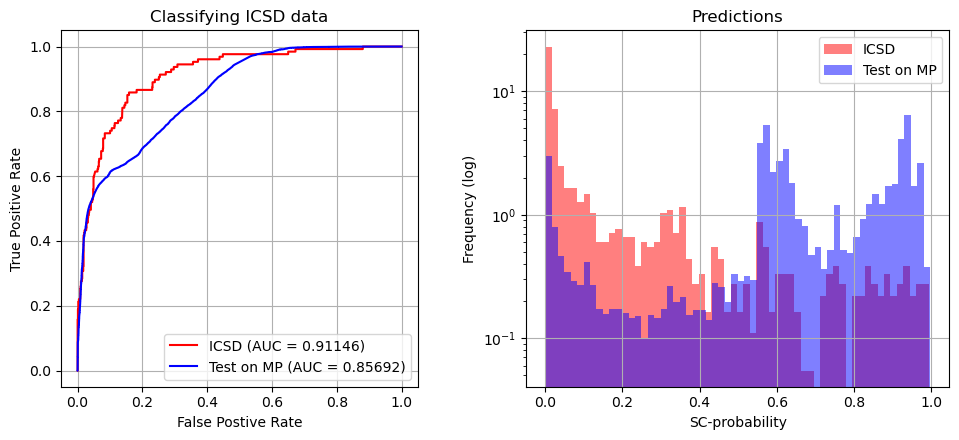

In [50]:
fig,[ax,axhist] = plt.subplots(1,2,figsize=(10,4.5))
ax.plot(fpr_ICSD,tpr_ICSD,label=f'ICSD (AUC = {auc_ICSD:5.5f})',color="red")
ax.plot(fpr_MPtest,tpr_MPtest,label=f'Test on MP (AUC = {auc_MPtest:5.5f})',color='blue')
ax.set_xlabel('False Postive Rate', size=10)
ax.set_ylabel('True Positive Rate', size=10)
ax.set_title(r'Classifying ICSD data')
ax.set_aspect('equal')
# ax.set_xlim(0,1)
# ax.set_ylim(0,1)
axhist.hist(preds_ICSD,alpha=0.5,color='red',density=True,bins=60,label='ICSD')
axhist.hist(preds_MPtest,alpha=0.5,color='blue',density=True,bins=60,label='Test on MP')
axhist.set_xlabel('SC-probability')
axhist.set_ylabel('Frequency (log)')
axhist.set_yscale('log')
axhist.set_title('Predictions')
ax.grid()
axhist.grid()

ax.legend()
axhist.legend()
fig.tight_layout()
fig.savefig('figs/roc_ICSD.png')
plt.show()

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

bound = 0.9

binary_MP_env = (preds_MP_env > bound).astype(int)
binary_MP_noenv = (preds_MP_noenv > bound).astype(int)
binary_ICSD = (preds_ICSD > bound).astype(int)
binary_MPtest = (preds_MPtest > bound).astype(int)

def conf_matrix(preds,targets,ax):
    cm = confusion_matrix(targets,preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax,colorbar=False)

Plot different classes seperatly

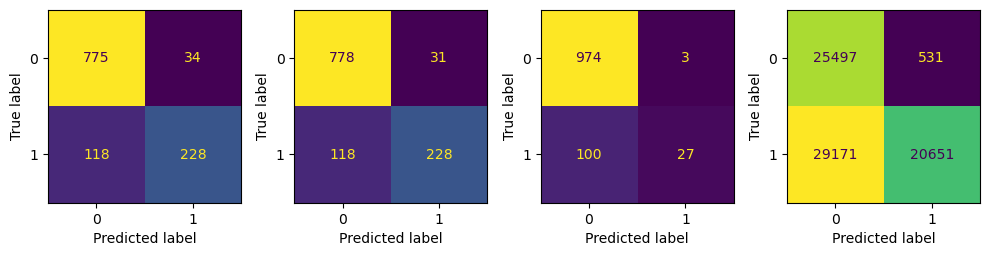

In [52]:
fig,ax = plt.subplots(1,4,figsize=(10,5))
conf_matrix(binary_MP_env,targets_MP,ax=ax[0])
conf_matrix(binary_MP_noenv,targets_MP,ax=ax[1])
conf_matrix(binary_ICSD,targets_ICSD,ax=ax[2])
conf_matrix(binary_MPtest,targets_MPtest,ax=ax[3])
fig.tight_layout()
plt.show()

In [53]:
accuracy_MP_env = accuracy_score(targets_MP,binary_MP_env)
accuracy_MP_noenv = accuracy_score(targets_MP,binary_MP_noenv)
accuracy_ICSD = accuracy_score(targets_ICSD,binary_ICSD)
accuracy_MPtest = accuracy_score(targets_MPtest,binary_MPtest)

In [55]:
accuracy_MP_noenv

0.870995670995671

In [54]:
accuracy_ICSD

0.9067028985507246